## ForecastOpti — Demand Forecasting & Inventory Optimization

## Data Understanding

### Objective

Understand the structure, quality, temporal coverage, and statistical
characteristics of the retail demand dataset before performing data
cleaning, feature engineering, and forecasting.

### Key Questions

1. What is the structure and granularity of the dataset?
2. What is the historical time coverage?
3. How many stores and items are available?
4. Is the store-item-date grain consistent?
5. Are there missing or duplicated observations?
6. How is demand distributed?
7. How do price and promotion relate to demand?
8. What temporal patterns exist?

### Principle

No modeling decisions will be made until the underlying demand data
has been properly understood and validated.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/ForecastOpti")
SRC_DIR = PROJECT_ROOT / "src"

print("Project exists :", PROJECT_ROOT.exists())
print("Project path   :", PROJECT_ROOT)

print("\nContents of ForecastOpti:")
for path in sorted(PROJECT_ROOT.iterdir()):
    print(" -", path.name)

print("\nSRC exists     :", SRC_DIR.exists())

if SRC_DIR.exists():
    print("\nContents of src:")
    for path in sorted(SRC_DIR.iterdir()):
        print(" -", path.name)

Project exists : True
Project path   : /content/drive/MyDrive/ForecastOpti

Contents of ForecastOpti:
 - data
 - figures
 - models
 - notebooks
 - outputs
 - src

SRC exists     : True

Contents of src:
 - __init__.py
 - __pycache__
 - bootstrap.py
 - config.py


In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/ForecastOpti")

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project root not found: {PROJECT_ROOT}"
    )

project_root_str = str(PROJECT_ROOT)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print("✓ Project root added to Python path.")
print(f"Python path: {project_root_str in sys.path}")

✓ Project root added to Python path.
Python path: True


In [ ]:
import importlib
import importlib.util
import sys

importlib.invalidate_caches()

# Remove any stale src module from the current kernel
sys.modules.pop("src", None)

spec = importlib.util.find_spec("src")

print("src found:", spec is not None)

if spec is not None:
    print("src origin:", spec.origin)
    print("src locations:", spec.submodule_search_locations)

src found: True
src origin: /content/drive/MyDrive/ForecastOpti/src/__init__.py
src locations: ['/content/drive/MyDrive/ForecastOpti/src']


In [ ]:
from src.config import (
    DATASET_PATH,
    EDA_FIGURES_DIR,
    SEED,
)

print("✓ src.config imported successfully")
print(f"Dataset : {DATASET_PATH}")
print(f"Figures : {EDA_FIGURES_DIR}")
print(f"Seed    : {SEED}")

✓ src.config imported successfully
Dataset : /content/drive/MyDrive/ForecastOpti/data/raw/retail_sales.csv
Figures : /content/drive/MyDrive/ForecastOpti/figures/eda
Seed    : 42


In [ ]:
from pathlib import Path

BOOTSTRAP_PATH = (
    Path("/content/drive/MyDrive/ForecastOpti")
    / "src"
    / "bootstrap.py"
)

bootstrap_content = '''
import sys
from pathlib import Path

from google.colab import drive


PROJECT_ROOT = Path("/content/drive/MyDrive/ForecastOpti")


def initialize_project():
    """Initialize the ForecastOpti Google Colab environment."""

    drive.mount("/content/drive")

    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"ForecastOpti project root not found: {PROJECT_ROOT}"
        )

    project_root_str = str(PROJECT_ROOT)

    if project_root_str not in sys.path:
        sys.path.insert(0, project_root_str)

    return PROJECT_ROOT
'''

BOOTSTRAP_PATH.write_text(
    bootstrap_content.strip() + "\n"
)

print(f"✓ Created: {BOOTSTRAP_PATH}")

✓ Created: /content/drive/MyDrive/ForecastOpti/src/bootstrap.py


In [ ]:
import importlib

importlib.invalidate_caches()

In [ ]:
from src.bootstrap import initialize_project

project_root = initialize_project()

print("✓ ForecastOpti initialized.")
print(f"Project root: {project_root}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ ForecastOpti initialized.
Project root: /content/drive/MyDrive/ForecastOpti


## 2. Data Loading

Load the complete raw dataset using memory-efficient data types.

The raw dataset is treated as immutable source data.

In [ ]:
import pandas as pd

from src.config import DATASET_PATH


DTYPES = {
    "store_id": "category",
    "item_id": "category",
    "sales": "int32",
    "price": "float32",
    "promo": "int8",
    "weekday": "int8",
    "month": "int8",
}

df = pd.read_csv(
    DATASET_PATH,
    dtype=DTYPES,
    parse_dates=["date"],
)

print(f"Rows    : {len(df):,}")
print(f"Columns : {len(df.columns)}")
print(
    f"Memory  : "
    f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

Rows    : 4,565,000
Columns : 8
Memory  : 91.43 MB


In [ ]:
dataset_summary = {
    "rows": len(df),
    "stores": df["store_id"].nunique(),
    "items": df["item_id"].nunique(),
    "dates": df["date"].nunique(),
    "start_date": df["date"].min(),
    "end_date": df["date"].max(),
}

pd.Series(dataset_summary, name="value")

,value
rows,4565000
stores,50
items,50
dates,1826
start_date,2019-01-01 00:00:00
end_date,2023-12-31 00:00:00


## 4. Data Grain Validation

Validate whether each observation represents exactly one
store-item-date combination.

Expected grain:

`1 row = 1 store × 1 item × 1 day`

In [ ]:
GRAIN_COLUMNS = [
    "date",
    "store_id",
    "item_id",
]

duplicate_grain_count = df.duplicated(
    subset=GRAIN_COLUMNS
).sum()

print(
    f"Duplicate store-item-date combinations: "
    f"{duplicate_grain_count:,}"
)

Duplicate store-item-date combinations: 0


In [ ]:
expected_date_count = (
    df["date"].max() - df["date"].min()
).days + 1

actual_date_count = df["date"].nunique()

print(f"Expected calendar days : {expected_date_count:,}")
print(f"Actual unique dates    : {actual_date_count:,}")

Expected calendar days : 1,826
Actual unique dates    : 1,826


In [ ]:
expected_dates = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D",
)

actual_dates = pd.DatetimeIndex(
    df["date"].unique()
).sort_values()

missing_dates = expected_dates.difference(
    actual_dates
)

print(f"Missing calendar dates: {len(missing_dates):,}")

Missing calendar dates: 0


In [ ]:
duplicate_grain_count = df.duplicated(
    subset=["date", "store_id", "item_id"]
).sum()

print(
    f"Duplicate store-item-date combinations: "
    f"{duplicate_grain_count:,}"
)

Duplicate store-item-date combinations: 0


## 5. Demand Profiling

Analyze the statistical characteristics of demand across stores,
items, and time.

### Objectives

- Understand the overall demand distribution.
- Measure demand variability.
- Identify zero-demand observations.
- Identify high-volume and low-volume items.
- Measure demand volatility using the coefficient of variation.
- Identify potential demand segments for downstream forecasting.

In [ ]:
demand_summary = df["sales"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

demand_summary

,sales
count,4.565000e+06
mean,2.926466e+01
std,1.500996e+01
min,0.000000e+00
1%,6.000000e+00
5%,1.000000e+01
25%,1.800000e+01
50%,2.700000e+01
75%,3.800000e+01
95%,5.700000e+01


In [ ]:
zero_demand_count = (df["sales"] == 0).sum()

zero_demand_rate = (
    zero_demand_count / len(df)
)

print(f"Zero-demand observations : {zero_demand_count:,}")
print(f"Zero-demand rate         : {zero_demand_rate:.2%}")


Zero-demand observations : 1,037
Zero-demand rate         : 0.02%


In [ ]:
item_demand = (
    df.groupby("item_id", observed=True)["sales"]
    .agg(
        total_sales="sum",
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
        min_sales="min",
        max_sales="max",
    )
)

item_demand["cv"] = (
    item_demand["std_sales"]
    / item_demand["mean_sales"]
)

item_demand.sort_values(
    "total_sales",
    ascending=False
).head(10)

,total_sales,mean_sales,median_sales,std_sales,min_sales,max_sales,cv
item_id,,,,,,,
item_20,4261507,46.675871,45.0,15.274123,11,139,0.327238
item_1,4207065,46.079573,44.0,15.162676,10,138,0.329054
item_3,4108554,45.000591,43.0,14.842693,11,133,0.329833
item_6,4051413,44.374732,42.0,14.599941,10,129,0.329015
item_4,3964580,43.423658,41.0,14.314841,9,127,0.329655
item_39,3938555,43.138609,41.0,14.221066,11,132,0.329660
item_31,3861901,42.299025,40.0,13.953555,10,128,0.329879
item_13,3752355,41.099179,39.0,13.592124,8,122,0.330715
item_24,3710934,40.645498,39.0,13.427709,9,118,0.330362


In [ ]:
item_demand = (
    df.groupby("item_id", observed=True)["sales"]
    .agg(
        total_sales="sum",
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
        min_sales="min",
        max_sales="max",
    )
)

item_demand["cv"] = (
    item_demand["std_sales"]
    / item_demand["mean_sales"]
)

item_demand = item_demand.sort_values(
    "total_sales",
    ascending=False
)

item_demand

,total_sales,mean_sales,median_sales,std_sales,min_sales,max_sales,cv
item_id,,,,,,,
item_20,4261507,46.675871,45.0,15.274123,11,139,0.327238
item_1,4207065,46.079573,44.0,15.162676,10,138,0.329054
item_3,4108554,45.000591,43.0,14.842693,11,133,0.329833
item_6,4051413,44.374732,42.0,14.599941,10,129,0.329015
item_4,3964580,43.423658,41.0,14.314841,9,127,0.329655
item_39,3938555,43.138609,41.0,14.221066,11,132,0.329660
item_31,3861901,42.299025,40.0,13.953555,10,128,0.329879
item_13,3752355,41.099179,39.0,13.592124,8,122,0.330715
item_24,3710934,40.645498,39.0,13.427709,9,118,0.330362


In [ ]:
store_demand = (
    df.groupby("store_id", observed=True)["sales"]
    .agg(
        total_sales="sum",
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
        min_sales="min",
        max_sales="max",
    )
)

store_demand["cv"] = (
    store_demand["std_sales"]
    / store_demand["mean_sales"]
)

store_demand.sort_values(
    "total_sales",
    ascending=False
)

,total_sales,mean_sales,median_sales,std_sales,min_sales,max_sales,cv
store_id,,,,,,,
store_12,3243496,35.525696,33.0,17.443000,0,136,0.490997
store_35,3240494,35.492815,33.0,17.496079,0,139,0.492947
store_2,3221215,35.281654,33.0,17.363198,0,133,0.492131
store_34,3218908,35.256386,33.0,17.390311,1,135,0.493253
store_44,3179667,34.826583,32.0,17.182307,0,135,0.493368
store_8,3132417,34.309058,32.0,16.938633,0,130,0.493707
store_13,3094882,33.897941,31.0,16.729744,0,132,0.493533
store_36,3069321,33.617974,31.0,16.606402,0,126,0.493974
store_26,3041146,33.309376,31.0,16.416777,0,130,0.492858


In [ ]:
store_demand["cv"].describe()

,cv
count,50.000000
mean,0.496620
std,0.002706
min,0.490997
25%,0.494570
50%,0.496257
75%,0.499170
max,0.501549


## 6. Temporal Demand Analysis

Analyze demand behavior over time to identify long-term trends,
weekly seasonality, and monthly seasonality.

The observed temporal patterns will guide feature engineering
and forecasting model design.

In [ ]:
daily_demand = (
    df.groupby("date", observed=True)["sales"]
    .agg(
        total_sales="sum",
        mean_sales="mean",
        median_sales="median",
    )
    .sort_index()
)

daily_demand.head()

,total_sales,mean_sales,median_sales
date,,,
2019-01-01,74119,29.6476,29.0
2019-01-02,77119,30.8476,30.0
2019-01-03,70810,28.3240,27.0
2019-01-04,59269,23.7076,23.0
2019-01-05,52621,21.0484,21.0


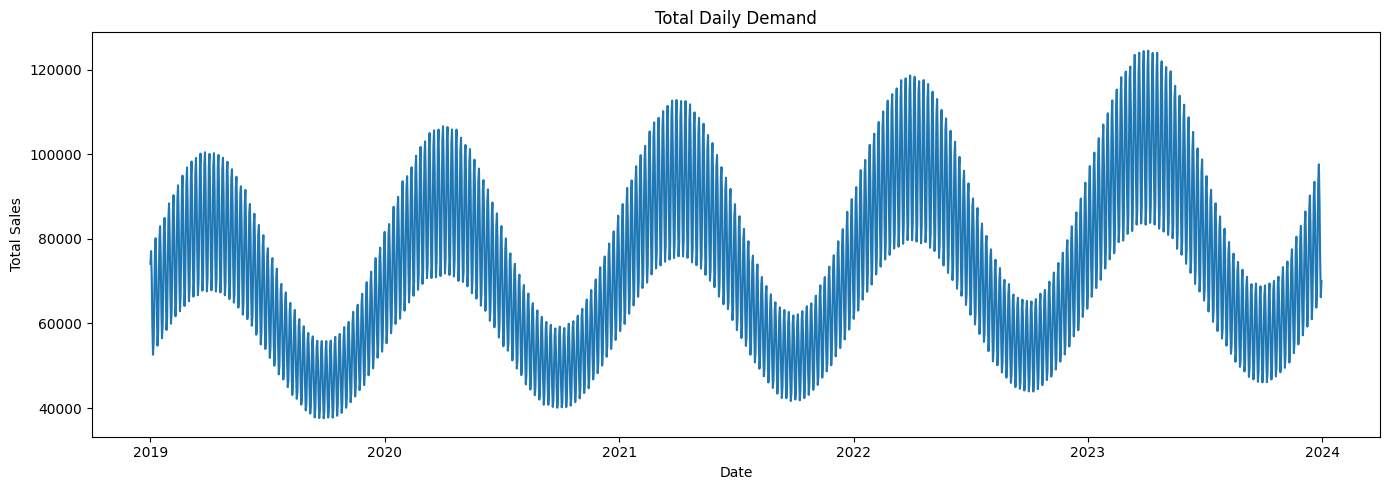

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand.index,
    daily_demand["total_sales"],
)

plt.title("Total Daily Demand")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "daily_total_demand.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [ ]:
df["day_of_week"] = df["date"].dt.dayofweek

weekly_pattern = (
    df.groupby("day_of_week", observed=True)["sales"]
    .agg(
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
    )
)

weekly_pattern.index = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekly_pattern

,mean_sales,median_sales,std_sales
Monday,29.261455,27.0,14.296260
Tuesday,33.830895,31.0,16.432194
Wednesday,34.973070,33.0,16.971338
Thursday,31.803810,30.0,15.470347
Friday,26.723387,25.0,13.107839
Saturday,23.569218,22.0,11.646576
Sunday,24.690774,23.0,12.169506


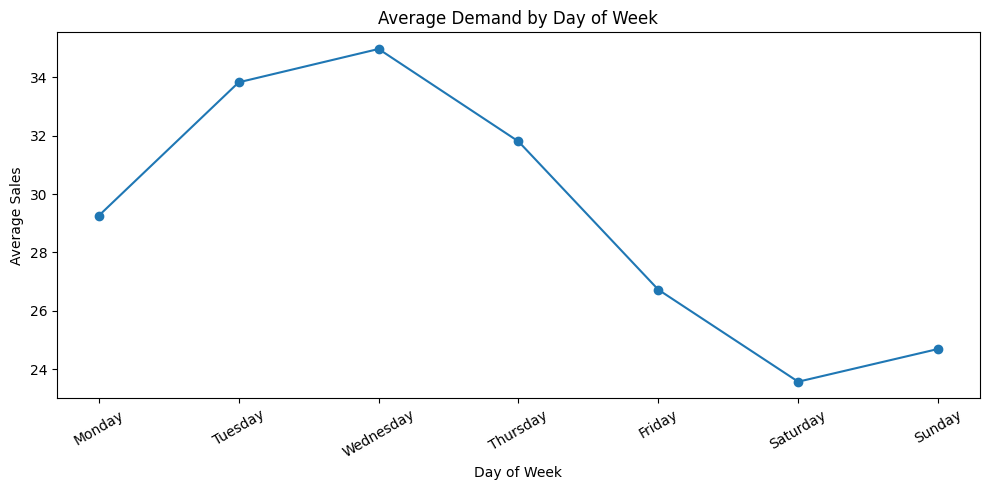

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    weekly_pattern.index,
    weekly_pattern["mean_sales"],
    marker="o",
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "weekly_seasonality.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [ ]:
monthly_pattern = (
    df.groupby(
        df["date"].dt.month,
        observed=True
    )["sales"]
    .agg(
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
    )
)

monthly_pattern

,mean_sales,median_sales,std_sales
date,,,
1,30.914839,29.0,14.332740
2,34.738460,33.0,16.007061
3,37.266640,35.0,17.137479
4,37.283355,36.0,17.055837
5,35.298155,34.0,16.288264
6,31.688797,30.0,14.681143
7,27.126852,26.0,12.642453
8,23.388498,22.0,11.059496
9,21.172549,20.0,10.008373


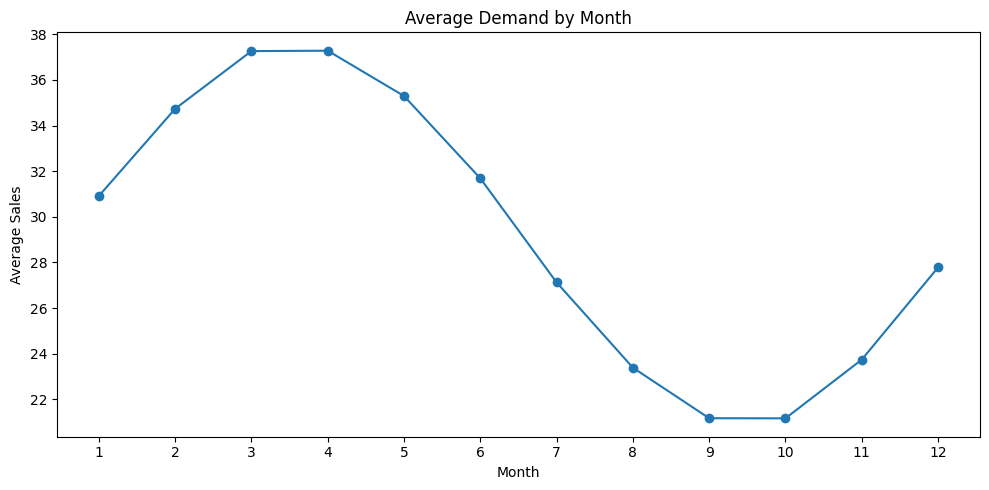

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_pattern.index,
    monthly_pattern["mean_sales"],
    marker="o",
)

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(range(1, 13))

plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "monthly_seasonality.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [ ]:
weekday_mismatch = (
    df["weekday"] != df["date"].dt.dayofweek
).sum()

month_mismatch = (
    df["month"] != df["date"].dt.month
).sum()

print(f"Weekday mismatches : {weekday_mismatch:,}")
print(f"Month mismatches   : {month_mismatch:,}")

Weekday mismatches : 0
Month mismatches   : 0


## 7. Price and Promotion Analysis

Analyze the relationship between price, promotion, and demand.

The objective is to understand whether price and promotional activity
contain predictive information that should be incorporated into
the forecasting models.

In [ ]:
price_summary = df["price"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

price_summary

,price
count,4.565000e+06
mean,5.399324e+01
std,2.571795e+01
min,8.020000e+00
1%,1.080000e+01
5%,1.427000e+01
25%,3.197000e+01
50%,5.352000e+01
75%,7.536000e+01
95%,9.534000e+01


In [ ]:
price_variability = (
    df.groupby("item_id", observed=True)["price"]
    .agg(
        mean_price="mean",
        median_price="median",
        min_price="min",
        max_price="max",
        std_price="std",
    )
)

price_variability

,mean_price,median_price,min_price,max_price,std_price
item_id,,,,,
item_1,56.015743,63.549999,8.09,95.790001,28.161863
item_10,50.840683,46.009998,9.33,98.349998,25.209412
item_11,54.361851,53.480000,12.19,97.169998,22.295595
item_12,61.386154,66.790001,9.55,99.400002,27.694412
item_13,53.852486,52.310001,11.04,98.070000,26.362776
item_14,55.132103,56.150002,12.85,96.750000,22.431856
item_15,57.078949,59.619999,11.00,99.269997,22.933229
item_16,49.271324,47.220001,8.17,96.430000,26.597635
item_17,51.703423,52.990002,8.55,98.919998,25.544737


In [ ]:
price_sales_corr = df[
    ["price", "sales"]
].corr()

price_sales_corr

,price,sales
price,1.000000,-0.059668
sales,-0.059668,1.000000


In [ ]:
item_price_corr = (
    df.groupby("item_id", observed=True)
    .apply(
        lambda x: x["price"].corr(x["sales"]),
        include_groups=False,
    )
    .rename("price_sales_correlation")
    .sort_values()
)

item_price_corr

,price_sales_correlation
item_id,
item_6,-0.205735
item_3,-0.190563
item_20,-0.149296
item_36,-0.136690
item_5,-0.131101
item_22,-0.125035
item_10,-0.118969
item_24,-0.118451
item_40,-0.116657


In [ ]:
price_summary

,price
count,4.565000e+06
mean,5.399324e+01
std,2.571795e+01
min,8.020000e+00
1%,1.080000e+01
5%,1.427000e+01
25%,3.197000e+01
50%,5.352000e+01
75%,7.536000e+01
95%,9.534000e+01


In [ ]:
item_price_corr

,price_sales_correlation
item_id,
item_6,-0.205735
item_3,-0.190563
item_20,-0.149296
item_36,-0.136690
item_5,-0.131101
item_22,-0.125035
item_10,-0.118969
item_24,-0.118451
item_40,-0.116657


In [ ]:
promo_summary = (
    df["promo"]
    .value_counts()
    .sort_index()
    .rename_axis("promo")
    .reset_index(name="observations")
)

promo_summary["percentage"] = (
    promo_summary["observations"]
    / len(df)
    * 100
)

promo_summary

,promo,observations,percentage
0,0,4108506,90.000131
1,1,456494,9.999869


In [ ]:
promo_demand = (
    df.groupby("promo", observed=True)["sales"]
    .agg(
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
        min_sales="min",
        max_sales="max",
    )
)

promo_demand

,mean_sales,median_sales,std_sales,min_sales,max_sales
promo,,,,,
0,27.864828,26.0,13.622044,0,96
1,41.863337,39.0,20.164090,0,139


In [ ]:
baseline_mean = promo_demand.loc[0, "mean_sales"]
promo_mean = promo_demand.loc[1, "mean_sales"]

promo_lift = (
    (promo_mean - baseline_mean)
    / baseline_mean
)

print(f"Promotion demand lift: {promo_lift:.2%}")

Promotion demand lift: 50.24%


In [ ]:
item_promo_demand = (
    df.groupby(["item_id", "promo"], observed=True)["sales"]
    .mean()
    .unstack()
    .rename(columns={
        0: "no_promo_mean",
        1: "promo_mean",
    })
)

item_promo_demand["promo_lift"] = (
    (
        item_promo_demand["promo_mean"]
        - item_promo_demand["no_promo_mean"]
    )
    / item_promo_demand["no_promo_mean"]
)

item_promo_demand = item_promo_demand.sort_values(
    "promo_lift",
    ascending=False
)

item_promo_demand

promo,no_promo_mean,promo_mean,promo_lift
item_id,,,
item_38,32.656025,49.278042,0.509003
item_43,36.808277,55.518941,0.508328
item_12,20.342983,30.677315,0.508005
item_3,42.818435,64.559035,0.507739
item_26,35.745500,53.892383,0.507669
item_25,35.007749,52.756929,0.507007
item_17,15.947947,24.009812,0.505511
item_19,13.718464,20.643435,0.504792
item_29,23.271206,35.015163,0.504656


In [ ]:
item_promo_demand["promo_lift"].describe()

,promo_lift
count,50.000000
mean,0.500466
std,0.004279
min,0.493056
25%,0.496749
50%,0.500315
75%,0.503048
max,0.509003
